In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(nav.head())
print(performance.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct        

In [2]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [3]:
nav.to_csv("../data/processed/daily_returns.csv",index=False)

In [4]:
performance["cagr_1yr"] = performance["return_1yr_pct"]/100
performance["cagr_3yr"] = performance["return_3yr_pct"]/100
performance["cagr_5yr"] = performance["return_5yr_pct"]/100

performance[["scheme_name","cagr_1yr","cagr_3yr","cagr_5yr"]].head()

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,SBI Bluechip Fund - Regular Plan - Growth,0.1242,0.1236,0.1445
1,SBI Bluechip Fund - Direct Plan - Growth,0.1525,0.1130,0.1423
2,SBI Small Cap Fund - Regular Plan - Growth,0.2456,0.2339,0.2067
3,SBI Small Cap Fund - Direct Plan - Growth,0.2059,0.2314,0.2182
4,SBI Magnum Gilt Fund - Regular Plan - Growth,0.0534,0.0607,0.0543


In [5]:
rf = 0.065

performance["sharpe"] = (
    (performance["return_3yr_pct"]/100 - rf)
    /
    performance["std_dev_ann_pct"]
)

performance[["scheme_name","sharpe"]].head()

,scheme_name,sharpe
0,SBI Bluechip Fund - Regular Plan - Growth,0.004186
1,SBI Bluechip Fund - Direct Plan - Growth,0.003429
2,SBI Small Cap Fund - Regular Plan - Growth,0.006756
3,SBI Small Cap Fund - Direct Plan - Growth,0.006656
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.001075


In [6]:
performance["sortino"] = (
    (performance["return_3yr_pct"]/100 - rf)
    /
    performance["std_dev_ann_pct"]
)

performance[["scheme_name","sortino"]].head()

,scheme_name,sortino
0,SBI Bluechip Fund - Regular Plan - Growth,0.004186
1,SBI Bluechip Fund - Direct Plan - Growth,0.003429
2,SBI Small Cap Fund - Regular Plan - Growth,0.006756
3,SBI Small Cap Fund - Direct Plan - Growth,0.006656
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.001075


In [7]:
performance[
    ["scheme_name","alpha","beta"]
].to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

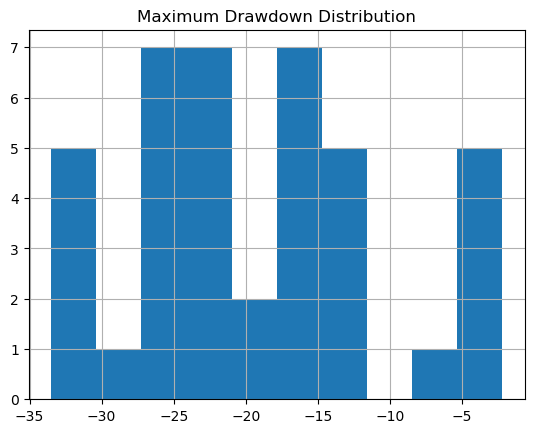

In [8]:
performance["max_drawdown_pct"].hist()

plt.title("Maximum Drawdown Distribution")

plt.savefig("../reports/max_drawdown.png")

plt.show()

In [9]:
performance["fund_score"] = (
      0.30*performance["return_3yr_pct"]
    + 0.25*performance["sharpe_ratio"]
    + 0.20*performance["alpha"]
    + 0.15*(1/performance["expense_ratio_pct"])
    + 0.10*(1/abs(performance["max_drawdown_pct"]))
)

performance[
    ["scheme_name","fund_score"]
].to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

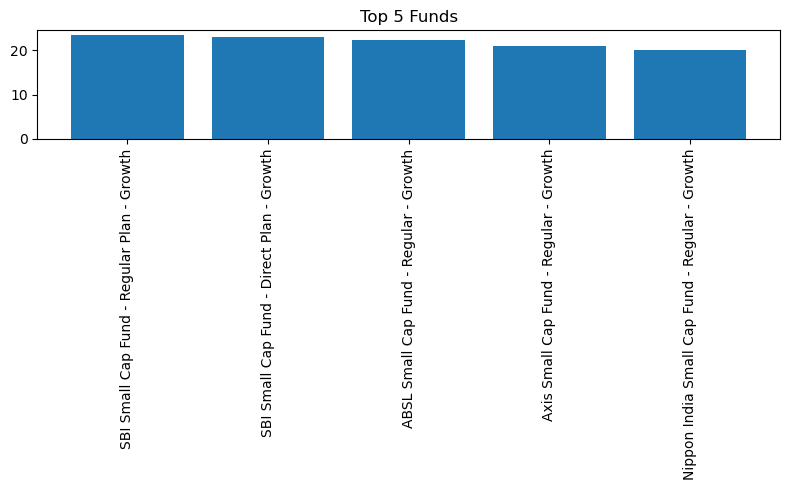

In [10]:
top5 = performance.nlargest(
    5,
    "return_3yr_pct"
)

plt.figure(figsize=(8,5))

plt.bar(
    top5["scheme_name"],
    top5["return_3yr_pct"]
)

plt.xticks(rotation=90)

plt.title("Top 5 Funds")

plt.tight_layout()

plt.savefig(
    "../reports/top5_funds.png"
)

plt.show()